In [ ]:
!pip install -q ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
online_retail = fetch_ucirepo(id=352)

df = online_retail.data.original.copy()

print("Dataset successfully loaded.")
print("Shape:", df.shape)

Dataset successfully loaded.
Shape: (541909, 8)


In [ ]:
df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 541909
Number of columns: 6

Column names:
['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.8+ MB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nMissing percentage:")
print((df.isnull().mean() * 100).round(2))

Missing values in each column:
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing percentage:
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 6007


In [ ]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 1.11%


In [ ]:
print("Quantity <= 0:")
print((df["Quantity"] <= 0).sum())

Quantity <= 0:
10624


In [ ]:
df[df["Quantity"] <= 0].head(20)

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
939,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom


In [ ]:
print("UnitPrice <= 0:")
print((df["UnitPrice"] <= 0).sum())

UnitPrice <= 0:
2517


In [ ]:
df[df["UnitPrice"] <= 0].head(20)

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
1988,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2024,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2025,NaN,3,12/1/2010 14:35,0.0,NaN,United Kingdom
2026,NaN,23,12/1/2010 14:35,0.0,NaN,United Kingdom
2406,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom


In [ ]:
cancellations = df[
    df["InvoiceNo"].astype(str).str.upper().str.startswith("C")
]

print("Cancellation transactions:", len(cancellations))

Cancellation transactions: 9288


In [ ]:
cancellations.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df_clean = df.copy()

In [ ]:
print("df.shape:", df.shape)

print("\nDataFrame columns:")
print(df.columns.tolist())

print("\nNumber of DataFrame columns:")
print(len(df.columns))

print("\nOriginal dataset columns:")
print(online_retail.data.original.columns.tolist())

print("\nOriginal dataset shape:")
print(online_retail.data.original.shape)

df.shape: (541909, 8)

DataFrame columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Number of DataFrame columns:
8

Original dataset columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Original dataset shape:
(541909, 8)


In [ ]:
print(online_retail.data.original.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [ ]:
missing_description = df[df["Description"].isnull()]

print("Rows with missing Description:", len(missing_description))

missing_description.head(20)

Rows with missing Description: 1454


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [ ]:
missing_description[[
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country"
]].head(20)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [ ]:
missing_customer = df[df["CustomerID"].isnull()]

print("Rows with missing CustomerID:", len(missing_customer))

missing_customer.head(20)

Rows with missing CustomerID: 135080


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


In [ ]:
missing_customer["Country"].value_counts().head(10)

,count
Country,
United Kingdom,133600
EIRE,711
Hong Kong,288
Unspecified,202
Switzerland,125
France,66
Israel,47
Portugal,39
Bahrain,2


In [ ]:
duplicates = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicates))

duplicates.head(20)

Total duplicate rows: 10147


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [ ]:
duplicates.sort_values(
    by=["InvoiceNo", "StockCode"]
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [ ]:
negative_quantity = df[df["Quantity"] < 0]
zero_quantity = df[df["Quantity"] == 0]

print("Negative quantities:", len(negative_quantity))
print("Zero quantities:", len(zero_quantity))

Negative quantities: 10624
Zero quantities: 0


In [ ]:
print("Negative quantity + cancellation invoice:")

print(
    negative_quantity["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .value_counts()
)

Negative quantity + cancellation invoice:
InvoiceNo
True     9288
False    1336
Name: count, dtype: int64


In [ ]:
cancellations = df[
    df["InvoiceNo"].astype(str).str.upper().str.startswith("C")
]

print("Cancellation transactions:", len(cancellations))

cancellations.head(20)

Cancellation transactions: 9288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [ ]:
print("Cancellation quantities:")

print(cancellations["Quantity"].describe())

Cancellation quantities:
count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64


In [ ]:
print("Cancellation UnitPrice:")

print(cancellations["UnitPrice"].describe())

Cancellation UnitPrice:
count     9288.000000
mean        48.393661
std        666.600430
min          0.010000
25%          1.450000
50%          2.950000
75%          5.950000
max      38970.000000
Name: UnitPrice, dtype: float64


In [ ]:
invalid_price = df[df["UnitPrice"] <= 0]

print("Rows with UnitPrice <= 0:", len(invalid_price))

invalid_price.head(20)

Rows with UnitPrice <= 0: 2517


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [ ]:
print("Zero UnitPrice:", (df["UnitPrice"] == 0).sum())
print("Negative UnitPrice:", (df["UnitPrice"] < 0).sum())

Zero UnitPrice: 2515
Negative UnitPrice: 2


In [ ]:
print(df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [ ]:
print("Quantity statistics:")
print(df["Quantity"].describe())

Quantity statistics:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64


In [ ]:
print("UnitPrice statistics:")
print(df["UnitPrice"].describe())

UnitPrice statistics:
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


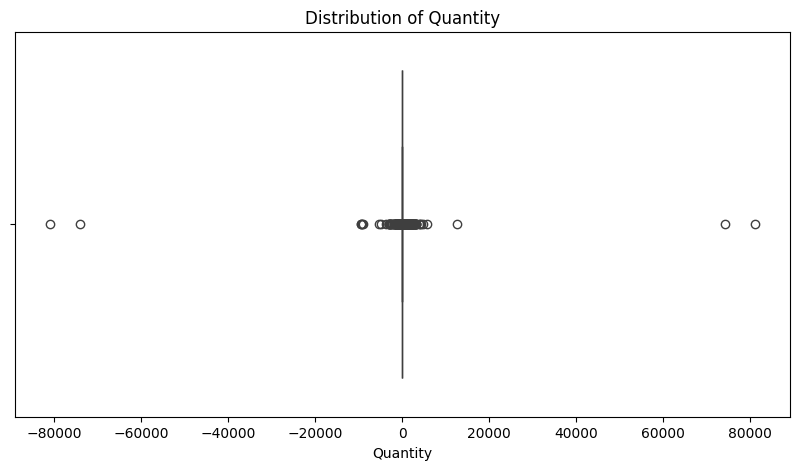

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Quantity"])
plt.title("Distribution of Quantity")
plt.xlabel("Quantity") plt.show()

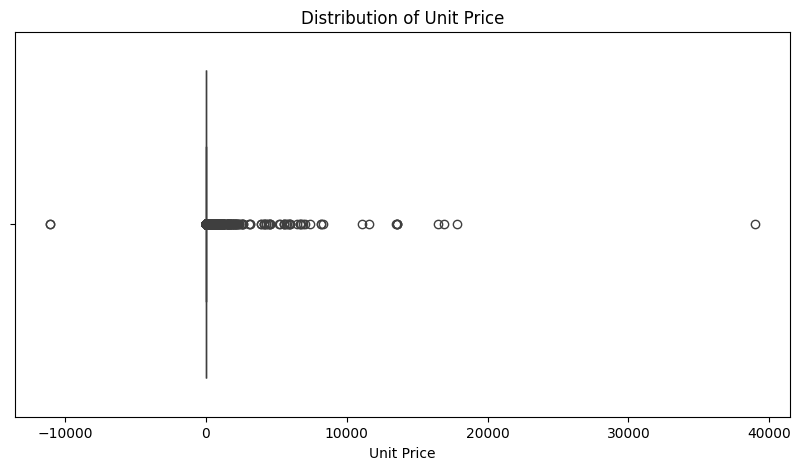

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["UnitPrice"])
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price") plt.show()

In [ ]:
largest_quantity = df.nlargest(20, "Quantity")

largest_quantity[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
74614,542504,37413,NaN,5568,2011-01-28 12:03:00,0.00,NaN,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
220843,556231,85123A,?,4000,2011-06-09 15:04:00,0.00,NaN,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom


In [ ]:
smallest_quantity = df.nsmallest(20, "Quantity")

smallest_quantity[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom
225528,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.00,NaN,United Kingdom
115818,546152,72140F,throw away,-5368,2011-03-09 17:25:00,0.00,NaN,United Kingdom
431381,573596,79323W,"Unsaleable, destroyed.",-4830,2011-10-31 15:17:00,0.00,NaN,United Kingdom
341601,566768,16045,NaN,-3667,2011-09-14 17:53:00,0.00,NaN,United Kingdom
323458,565304,16259,NaN,-3167,2011-09-02 12:18:00,0.00,NaN,United Kingdom


In [ ]:
largest_price = df.nlargest(20, "UnitPrice")

largest_price[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom


In [ ]:
smallest_price = df.nsmallest(20, "UnitPrice")

smallest_price[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.00,NaN,United Kingdom


In [ ]:
negative_non_cancellation = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

print("Negative quantity without cancellation invoice:",
      len(negative_non_cancellation))

negative_non_cancellation.head(30)

Negative quantity without cancellation invoice: 1336


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [ ]:
negative_non_cancellation[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "CustomerID", "Country"]
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,0.0,NaN,United Kingdom


In [ ]:
zero_price = df[df["UnitPrice"] == 0]

print("Zero-price records:", len(zero_price))

zero_price.head(30)

Zero-price records: 2515


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [ ]:
zero_price["Description"].value_counts().head(20)

,count
Description,
check,159
?,47
damages,45
damaged,43
found,25
sold as set on dotcom,20
adjustment,16
Damaged,14
"Unsaleable, destroyed.",9


In [ ]:
negative_price = df[df["UnitPrice"] < 0]

negative_price

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [ ]:
Q1_quantity = df["Quantity"].quantile(0.25)
Q3_quantity = df["Quantity"].quantile(0.75)

IQR_quantity = Q3_quantity - Q1_quantity

lower_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_quantity = Q3_quantity + 1.5 * IQR_quantity

print("Quantity Q1:", Q1_quantity)
print("Quantity Q3:", Q3_quantity)
print("Quantity IQR:", IQR_quantity)
print("Lower bound:", lower_quantity)
print("Upper bound:", upper_quantity)

Quantity Q1: 1.0
Quantity Q3: 10.0
Quantity IQR: 9.0
Lower bound: -12.5
Upper bound: 23.5


In [ ]:
Q1_price = df["UnitPrice"].quantile(0.25)
Q3_price = df["UnitPrice"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

print("UnitPrice Q1:", Q1_price)
print("UnitPrice Q3:", Q3_price)
print("UnitPrice IQR:", IQR_price)
print("Lower bound:", lower_price)
print("Upper bound:", upper_price)

UnitPrice Q1: 1.25
UnitPrice Q3: 4.13
UnitPrice IQR: 2.88
Lower bound: -3.0700000000000003
Upper bound: 8.45


In [ ]:
quantity_outliers = df[
    (df["Quantity"] < lower_quantity) |
    (df["Quantity"] > upper_quantity)
]

price_outliers = df[
    (df["UnitPrice"] < lower_price) |
    (df["UnitPrice"] > upper_price)
]

print("Potential Quantity outliers:", len(quantity_outliers))
print("Potential UnitPrice outliers:", len(price_outliers))

Potential Quantity outliers: 58619
Potential UnitPrice outliers: 39627


In [ ]:
quantity_outliers = df[
    (df["Quantity"] < lower_quantity) |
    (df["Quantity"] > upper_quantity)
]

price_outliers = df[
    (df["UnitPrice"] < lower_price) |
    (df["UnitPrice"] > upper_price)
]

print("Potential Quantity outliers:", len(quantity_outliers))
print("Potential UnitPrice outliers:", len(price_outliers))

Potential Quantity outliers: 58619
Potential UnitPrice outliers: 39627


In [ ]:
clean_df = df.copy()

print("Original shape:", clean_df.shape)

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Remove rows with missing Description
clean_df = clean_df.dropna(subset=["Description"])

# Remove rows with missing CustomerID
clean_df = clean_df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
clean_df = clean_df[~clean_df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove non-positive quantities
clean_df = clean_df[clean_df["Quantity"] > 0]

# Remove non-positive unit prices
clean_df = clean_df[clean_df["UnitPrice"] > 0]

print("Cleaned shape:", clean_df.shape)
print("Rows removed:", df.shape[0] - clean_df.shape[0])

Original shape: (541909, 8)
Cleaned shape: (392692, 8)
Rows removed: 149217


In [ ]:
print("===== CLEANED DATA VALIDATION =====")

print("\n1. Dataset shape:")
print(clean_df.shape)

print("\n2. Missing values:")
print(clean_df.isnull().sum())

print("\n3. Duplicate rows:")
print(clean_df.duplicated().sum())

print("\n4. Negative quantities:")
print((clean_df["Quantity"] < 0).sum())

print("\n5. Zero quantities:")
print((clean_df["Quantity"] == 0).sum())

print("\n6. Non-positive UnitPrice:")
print((clean_df["UnitPrice"] <= 0).sum())

print("\n7. Cancelled invoices:")
print(clean_df["InvoiceNo"].astype(str).str.startswith("C").sum())

print("\n8. Data types:")
print(clean_df.dtypes)

===== CLEANED DATA VALIDATION =====

1. Dataset shape:
(392692, 8)

2. Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

3. Duplicate rows:
0

4. Negative quantities:
0

5. Zero quantities:
0

6. Non-positive UnitPrice:
0

7. Cancelled invoices:
0

8. Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [ ]:
# Convert CustomerID to integer
clean_df["CustomerID"] = clean_df["CustomerID"].astype(int)

# Create total transaction amount
clean_df["TotalAmount"] = clean_df["Quantity"] * clean_df["UnitPrice"]

# Extract date and time features
clean_df["Year"] = clean_df["InvoiceDate"].dt.year
clean_df["Month"] = clean_df["InvoiceDate"].dt.month
clean_df["Day"] = clean_df["InvoiceDate"].dt.day
clean_df["Hour"] = clean_df["InvoiceDate"].dt.hour

print("Preprocessing completed successfully.")

print("\nUpdated shape:")
print(clean_df.shape)

print("\nUpdated columns:")
print(clean_df.columns.tolist())

print("\nData types:")
print(clean_df.dtypes)

Preprocessing completed successfully.

Updated shape:
(392692, 13)

Updated columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Year', 'Month', 'Day', 'Hour']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalAmount           float64
Year                    int32
Month                   int32
Day                     int32
Hour                    int32
dtype: object


In [ ]:
print("===== FINAL PREPROCESSING VALIDATION =====")

print("\n1. Missing values:")
print(clean_df.isnull().sum())

print("\n2. Duplicate rows:")
print(clean_df.duplicated().sum())

print("\n3. Quantity validation:")
print("Minimum Quantity:", clean_df["Quantity"].min())
print("Maximum Quantity:", clean_df["Quantity"].max())

print("\n4. UnitPrice validation:")
print("Minimum UnitPrice:", clean_df["UnitPrice"].min())
print("Maximum UnitPrice:", clean_df["UnitPrice"].max())

print("\n5. TotalAmount validation:")
print("Minimum TotalAmount:", clean_df["TotalAmount"].min())
print("Maximum TotalAmount:", clean_df["TotalAmount"].max())

print("\n6. InvoiceDate range:")
print("Start Date:", clean_df["InvoiceDate"].min())
print("End Date:", clean_df["InvoiceDate"].max())

print("\n7. Customer count:")
print(clean_df["CustomerID"].nunique())

print("\n8. Invoice count:")
print(clean_df["InvoiceNo"].nunique())

print("\n9. Country count:")
print(clean_df["Country"].nunique())

print("\n10. Final dataset shape:")
print(clean_df.shape)

===== FINAL PREPROCESSING VALIDATION =====

1. Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
Year           0
Month          0
Day            0
Hour           0
dtype: int64

2. Duplicate rows:
0

3. Quantity validation:
Minimum Quantity: 1
Maximum Quantity: 80995

4. UnitPrice validation:
Minimum UnitPrice: 0.001
Maximum UnitPrice: 8142.75

5. TotalAmount validation:
Minimum TotalAmount: 0.001
Maximum TotalAmount: 168469.6

6. InvoiceDate range:
Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00

7. Customer count:
4338

8. Invoice count:
18532

9. Country count:
37

10. Final dataset shape:
(392692, 13)


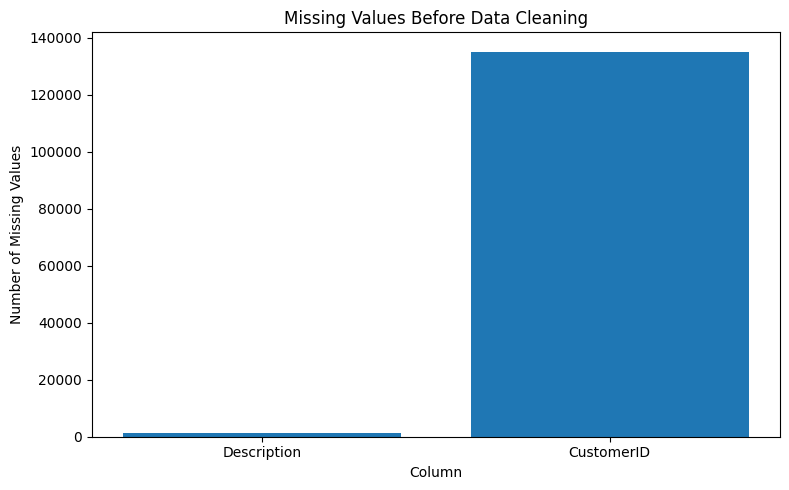

In [ ]:
import matplotlib.pyplot as plt

missing_data = {
    "Description": 1454,
    "CustomerID": 135080
}

plt.figure(figsize=(8, 5))

plt.bar(missing_data.keys(), missing_data.values())

plt.title("Missing Values Before Data Cleaning")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")

plt.tight_layout()
plt.show()

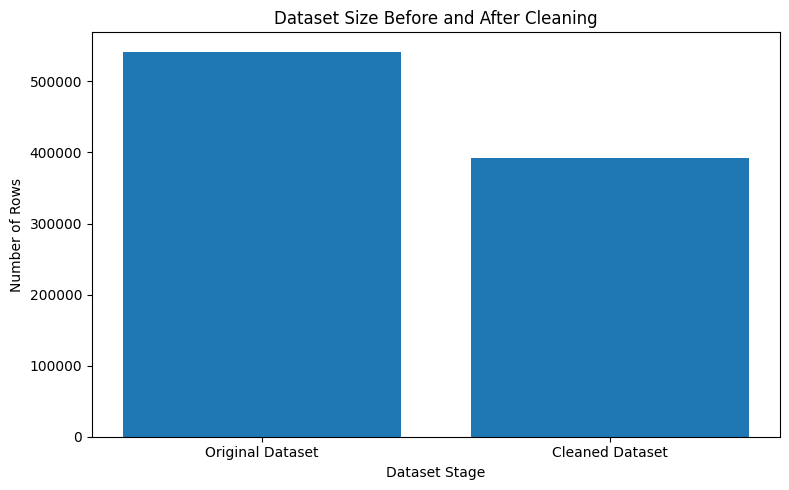

In [ ]:
import matplotlib.pyplot as plt

stages = ["Original Dataset", "Cleaned Dataset"]
rows = [541909, 392692]

plt.figure(figsize=(8, 5))

plt.bar(stages, rows)

plt.title("Dataset Size Before and After Cleaning")
plt.xlabel("Dataset Stage")
plt.ylabel("Number of Rows")

plt.tight_layout()
plt.show()

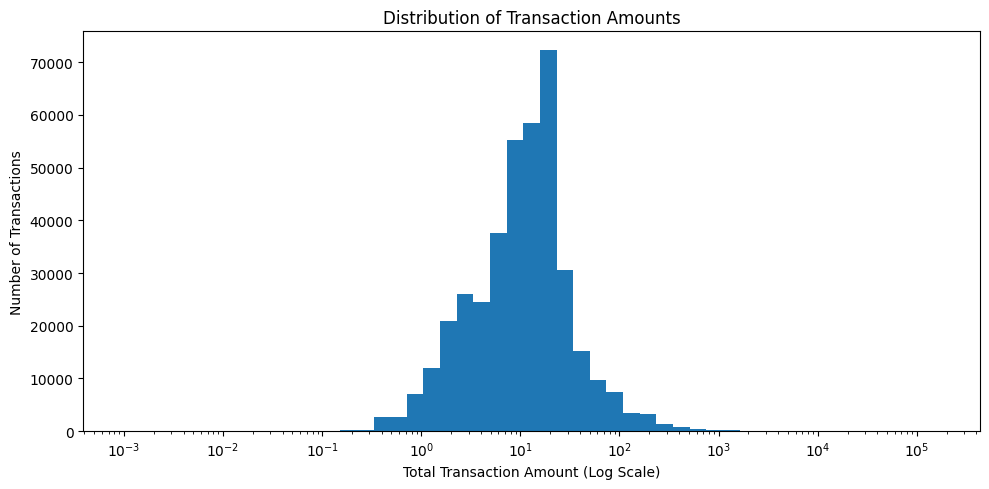

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

amounts = clean_df["TotalAmount"]

# Create logarithmically spaced bins
bins = np.logspace(
    np.log10(amounts.min()),
    np.log10(amounts.max()),
    50
)

plt.figure(figsize=(10, 5))

plt.hist(amounts, bins=bins)

plt.xscale("log")

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Total Transaction Amount (Log Scale)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()